# DC-QAOA Visualization Notebook
This notebook runs the DC-QAOA Max-Cut pipeline step-by-step and visualizes the problem graph, subgraph partitions, and the final optimized solution.

In [ ]:
import sys
import ast
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

from pathlib import Path
from typing import Optional

from d

import solver as _solver_module
from graph_loader import load_graph
from partitioner import recursive_partition, PartitionNode
from solver import qaoa_solve, setup_qpu, USE_PYQUIL, _local_search
from merger import merge
from scorer import maxcut_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

## 1. Helper Functions for Visualization

In [2]:
def draw_graph(G: nx.Graph, title: str, node_colors: list = None, pos: dict = None):
    """Helper to draw a NetworkX graph nicely."""
    plt.figure(figsize=(10, 8))
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
        
    if node_colors is None:
        node_colors = ['skyblue'] * G.number_of_nodes()
        
    edges = G.edges(data=True)
    weights = [d.get('weight', 1.0) for u, v, d in edges]
    max_weight = max(weights) if weights else 1.0
    edge_widths = [1 + 3 * (w / max_weight) for w in weights]

    nx.draw(G, pos, 
            node_color=node_colors, 
            with_labels=True, 
            node_size=600, 
            font_size=10, 
            font_color='black',
            font_weight='bold',
            edge_color='gray', 
            width=edge_widths, 
            alpha=0.9)
    
    plt.title(title, fontsize=16)
    plt.margins(x=0.1, y=0.1)
    plt.show()
    return pos

## 2. Configuration & Load Graph

Setting up QPU: 9q-square-qvm...
[solver] Quantum computer set -> 9q-square-qvm

Loading graph from ../dataset_A.csv...
[graph_loader] Loaded graph: 21 nodes, 28 edges  |  avg degree = 2.67
Loaded graph with 21 nodes and 28 edges.


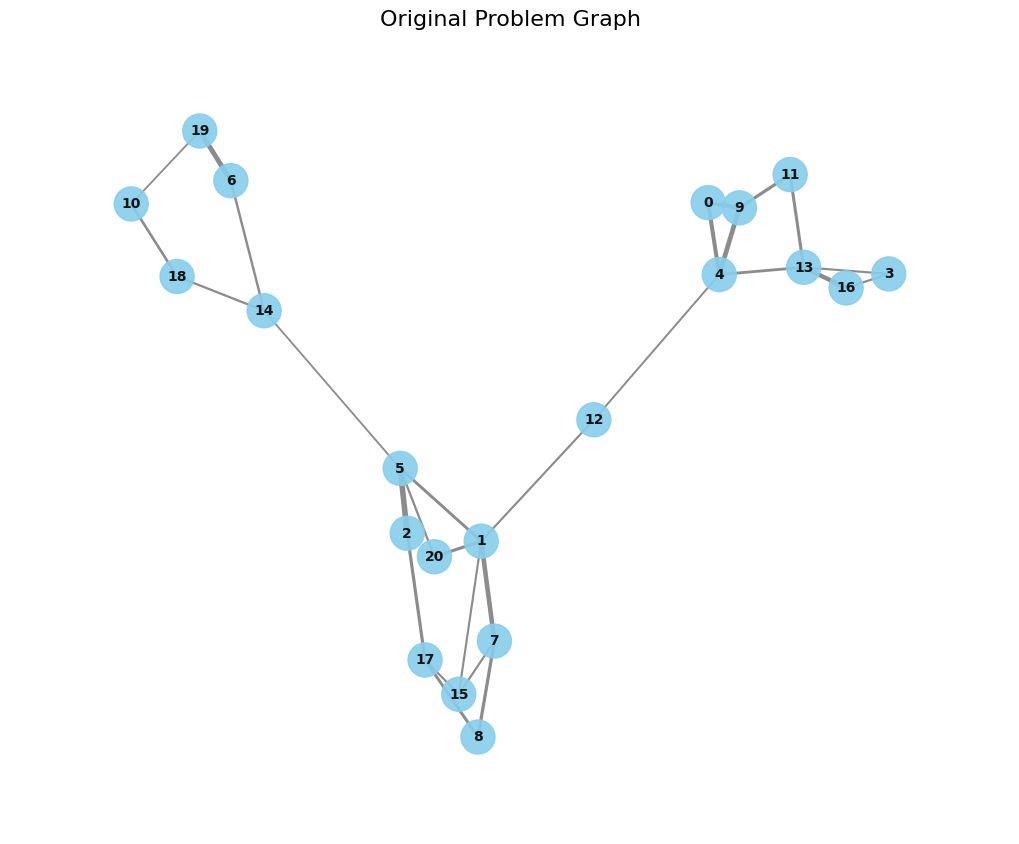

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [3]:
# ── Pipeline settings ────────────────────────────────────────────────────────
GRAPH_PATH = Path("../dataset_A.csv")
MAX_SIZE   = 8
TOP_T      = 10
c   # "separator" (NaiveLGP) | "community"

# ── QVM / QPU connection ─────────────────────────────────────────────────────
import os
os.environ["QCS_SETTINGS_APPLICATIONS_QVM_URL"] = "http://127.0.0.1:5001"

# ── Solver knobs ─────────────────────────────────────────────────────────────
_solver_module.USE_PYQUIL   = True    # False → stub (brute-force / local search)
_solver_module.LAYER_COUNT  = 1       # QAOA depth p
_solver_module.SHOTS        = 1024
_solver_module.SEED         = 42

# ── Quantum computer target ───────────────────────────────────────────────────
QC_NAME = "9q-square-qvm"

if _solver_module.USE_PYQUIL and QC_NAME:
    print(f"Setting up QPU: {QC_NAME}...")
    setup_qpu(QC_NAME)

# ── Load graph ────────────────────────────────────────────────────────────────
print(f"\nLoading graph from {GRAPH_PATH}...")
G = load_graph(GRAPH_PATH)
print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

global_pos = nx.spring_layout(G, seed=42)
draw_graph(G, "Original Problem Graph", pos=global_pos)


## 2b. Mixer Mode Selection

Choose which QAOA mixer to use.  The mixer defines the *driver Hamiltonian*
$B$ that explores the solution space between cost-layer applications.

| Mode | Operator | Initial state | Ring gates / layer | Notes |
|------|----------|---------------|--------------------|-------|
| `"X"`  | $\sum_j X_j$ | $\|+\rangle^n$ | 0 (single-qubit only) | Standard transverse-field; best for noisy hardware |
| `"XX"` | $\sum_{(i,j)\in\text{ring}} X_iX_j$ | $\|+\rangle^n$ | $n$ CNOT pairs | Stronger correlations; more expressive at equal depth |
| `"XY"` | $\sum_{(i,j)\in\text{ring}} \frac{X_iX_j+Y_iY_j}{2}$ | $\|1^k0^k\rangle$, $k=n/2$ | $2n$ CNOT pairs | **Conserves Hamming weight** — start state must have weight $n/2$ |

> **XY caution**: starting from $|+\rangle^n$ with the XY mixer is wrong —
> the mixer cannot move amplitude between Hamming-weight sectors, so each
> sector evolves in isolation and most never reach a good cut partition.
> The solver initialises $k = \lfloor n/2 \rfloor$ qubits to $|1\rangle$ automatically.


In [4]:
# ── Mixer mode selection ──────────────────────────────────────────────────────
# Set MIXER_MODE to one of: "X", "XX", "XY"
MIXER_MODE = "X"

_MIXER_DESCRIPTIONS = {
    "X":  ("Standard transverse-field",
           "exp(-i β Σ X_j)  — single-qubit RX rotations, lowest gate cost"),
    "XX": ("Graph-coupled XX",
           "exp(-i β Σ_{ring} X_iX_j)  — two-qubit XX on ring, richer correlations"),
    "XY": ("XY conserving mixer",
           "exp(-i β Σ_{ring} (X_iX_j+Y_iY_j)/2)  — preserves Hamming weight"),
}

if MIXER_MODE not in _MIXER_DESCRIPTIONS:
    raise ValueError(f"Unknown MIXER_MODE {MIXER_MODE!r}. Choose from {list(_MIXER_DESCRIPTIONS)}")

_solver_module.MIXER_MODE = MIXER_MODE
name, formula = _MIXER_DESCRIPTIONS[MIXER_MODE]

print(f"{'─'*55}")
print(f"  Mixer mode  : {MIXER_MODE!r}")
print(f"  Name        : {name}")
print(f"  Operator    : {formula}")
print(f"{'─'*55}")


───────────────────────────────────────────────────────
  Mixer mode  : 'X'
  Name        : Standard transverse-field
  Operator    : exp(-i β Σ X_j)  — single-qubit RX rotations, lowest gate cost
───────────────────────────────────────────────────────


## 3. Graph Partitioning

Partitioning graph (method=separator, max_size=8)...
[partitioner] Splitting: 21 nodes, 28 edges  (method=separator)
[partitioner]  -> |A|=2, |S|=1, |B|=18  (2^|S|=2 separator combos at merge)
[partitioner] Splitting: 19 nodes, 25 edges  (method=separator)
[partitioner]  -> |A|=13, |S|=1, |B|=5  (2^|S|=2 separator combos at merge)
[partitioner] Splitting: 14 nodes, 19 edges  (method=separator)
[partitioner]  -> |A|=6, |S|=1, |B|=7  (2^|S|=2 separator combos at merge)
Created 4 leaf subgraphs.


/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_25291/4104542379.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(leaves))


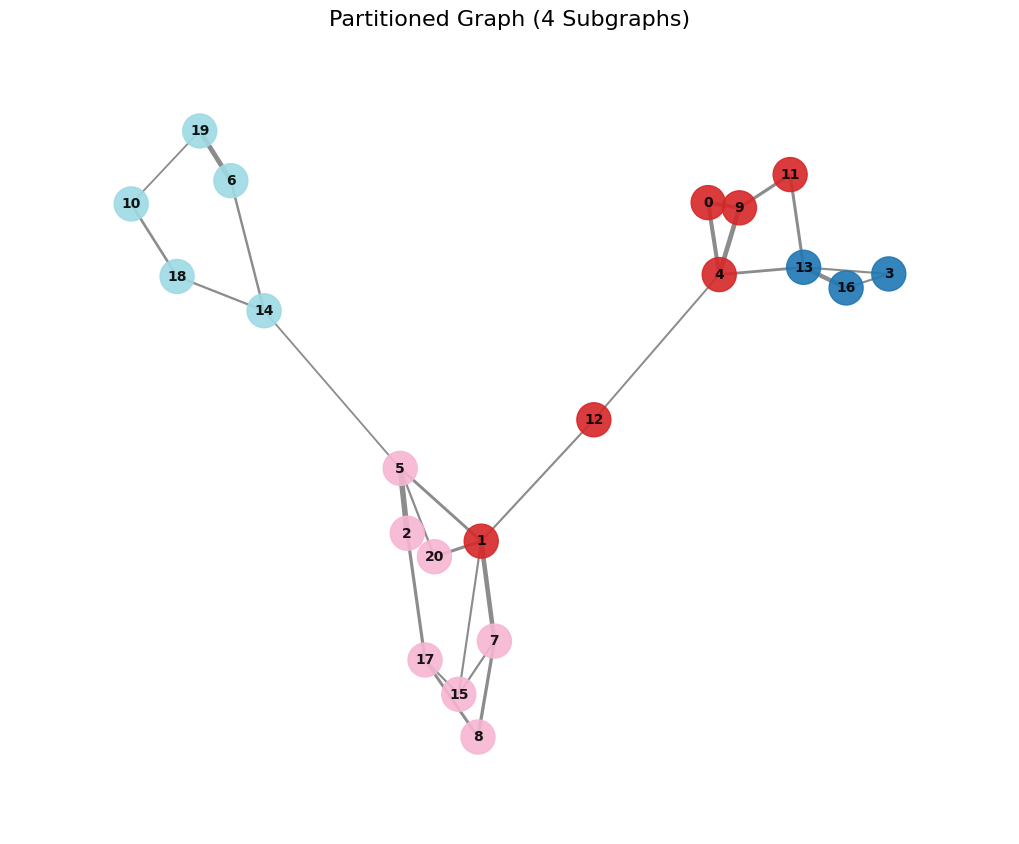

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [5]:
print(f"Partitioning graph (method={METHOD}, max_size={MAX_SIZE})...")
partition_tree = recursive_partition(G, max_size=MAX_SIZE, method=METHOD)
leaves = partition_tree.leaves()

print(f"Created {len(leaves)} leaf subgraphs.")

# Assign a distinct color index to each leaf subgraph
node_to_leaf_idx = {}
for i, leaf in enumerate(leaves):
    for node in leaf.graph.nodes():
        if node not in node_to_leaf_idx:
            node_to_leaf_idx[node] = i

# Map indices to unique colors
cmap = plt.cm.get_cmap('tab20', len(leaves))
colors = [cmap(node_to_leaf_idx.get(n, 0)) for n in G.nodes()]

draw_graph(G, f"Partitioned Graph ({len(leaves)} Subgraphs)", node_colors=colors, pos=global_pos)

## 4. Solve Leaf Subgraphs with QAOA

In [6]:
subgraph_solutions = {}

for i, leaf in enumerate(leaves):
    n_nodes = leaf.graph.number_of_nodes()
    backend = "pyQuil" if _solver_module.USE_PYQUIL else "stub"
    print(f"\n--- Solving Leaf {i + 1}/{len(leaves)} ---")
    print(f"Nodes: {n_nodes}, Edges: {leaf.graph.number_of_edges()} [{backend}]")
    
    # Solve (QAOA or stub)
    solutions = qaoa_solve(leaf.graph, top_t=TOP_T)
    subgraph_solutions[id(leaf)] = solutions
    
    best = maxcut_score(leaf.graph, solutions[0]) if solutions else 0.0
    print(f"-> Found {len(solutions)} solution(s). Best subgraph cut = {best:.4f}")


--- Solving Leaf 1/4 ---
Nodes: 3, Edges: 3 [pyQuil]
[solver] Gate estimate: 3 qubits, 3 edges, p=1 -> ~27 native 2Q gates (OK)
[solver] QAOA best E[cut]: 332.9279 (from 5 starts)
[solver] Optimal params | gammas=['-2.3359'] | betas=['-0.3114'] | trial 5/5
-> Found 8 solution(s). Best subgraph cut = 347.6181

--- Solving Leaf 2/4 ---
Nodes: 7, Edges: 8 [pyQuil]
[solver] Gate estimate: 7 qubits, 8 edges, p=1 -> ~72 native 2Q gates (OK)
[solver] QAOA best E[cut]: 839.6115 (from 5 starts)
[solver] Optimal params | gammas=['2.1554'] | betas=['1.1962'] | trial 2/5
-> Found 10 solution(s). Best subgraph cut = 1124.5230

--- Solving Leaf 3/4 ---
Nodes: 8, Edges: 11 [pyQuil]
[solver] Gate estimate: 8 qubits, 11 edges, p=1 -> ~99 native 2Q gates (OK)
[solver] QAOA best E[cut]: 1063.6017 (from 5 starts)
[solver] Optimal params | gammas=['-3.2840'] | betas=['0.4782'] | trial 5/5
-> Found 10 solution(s). Best subgraph cut = 1605.0910

--- Solving Leaf 4/4 ---
Nodes: 6, Edges: 6 [pyQuil]
[solver] 

## 4b. Optimization History — E[Cut] per COBYLA trial

Each line is one COBYLA multi-start run.  The quantity plotted is
$\mathbb{E}[\text{cut}]$, the **average weighted cut** over all measurement
shots at each COBYLA function evaluation — **higher is better**.

The solver stores these traces in `_solver_module.OPTIMIZATION_HISTORY`
(only populated when `USE_PYQUIL = True`).

> **Why not plot "loss"?**  COBYLA minimises $-\mathbb{E}[\text{cut}]$.
> Plotting the raw cut value is more interpretable — you can read off the
> approximate ratio directly.  A second panel shows the loss (negated) for
> completeness.


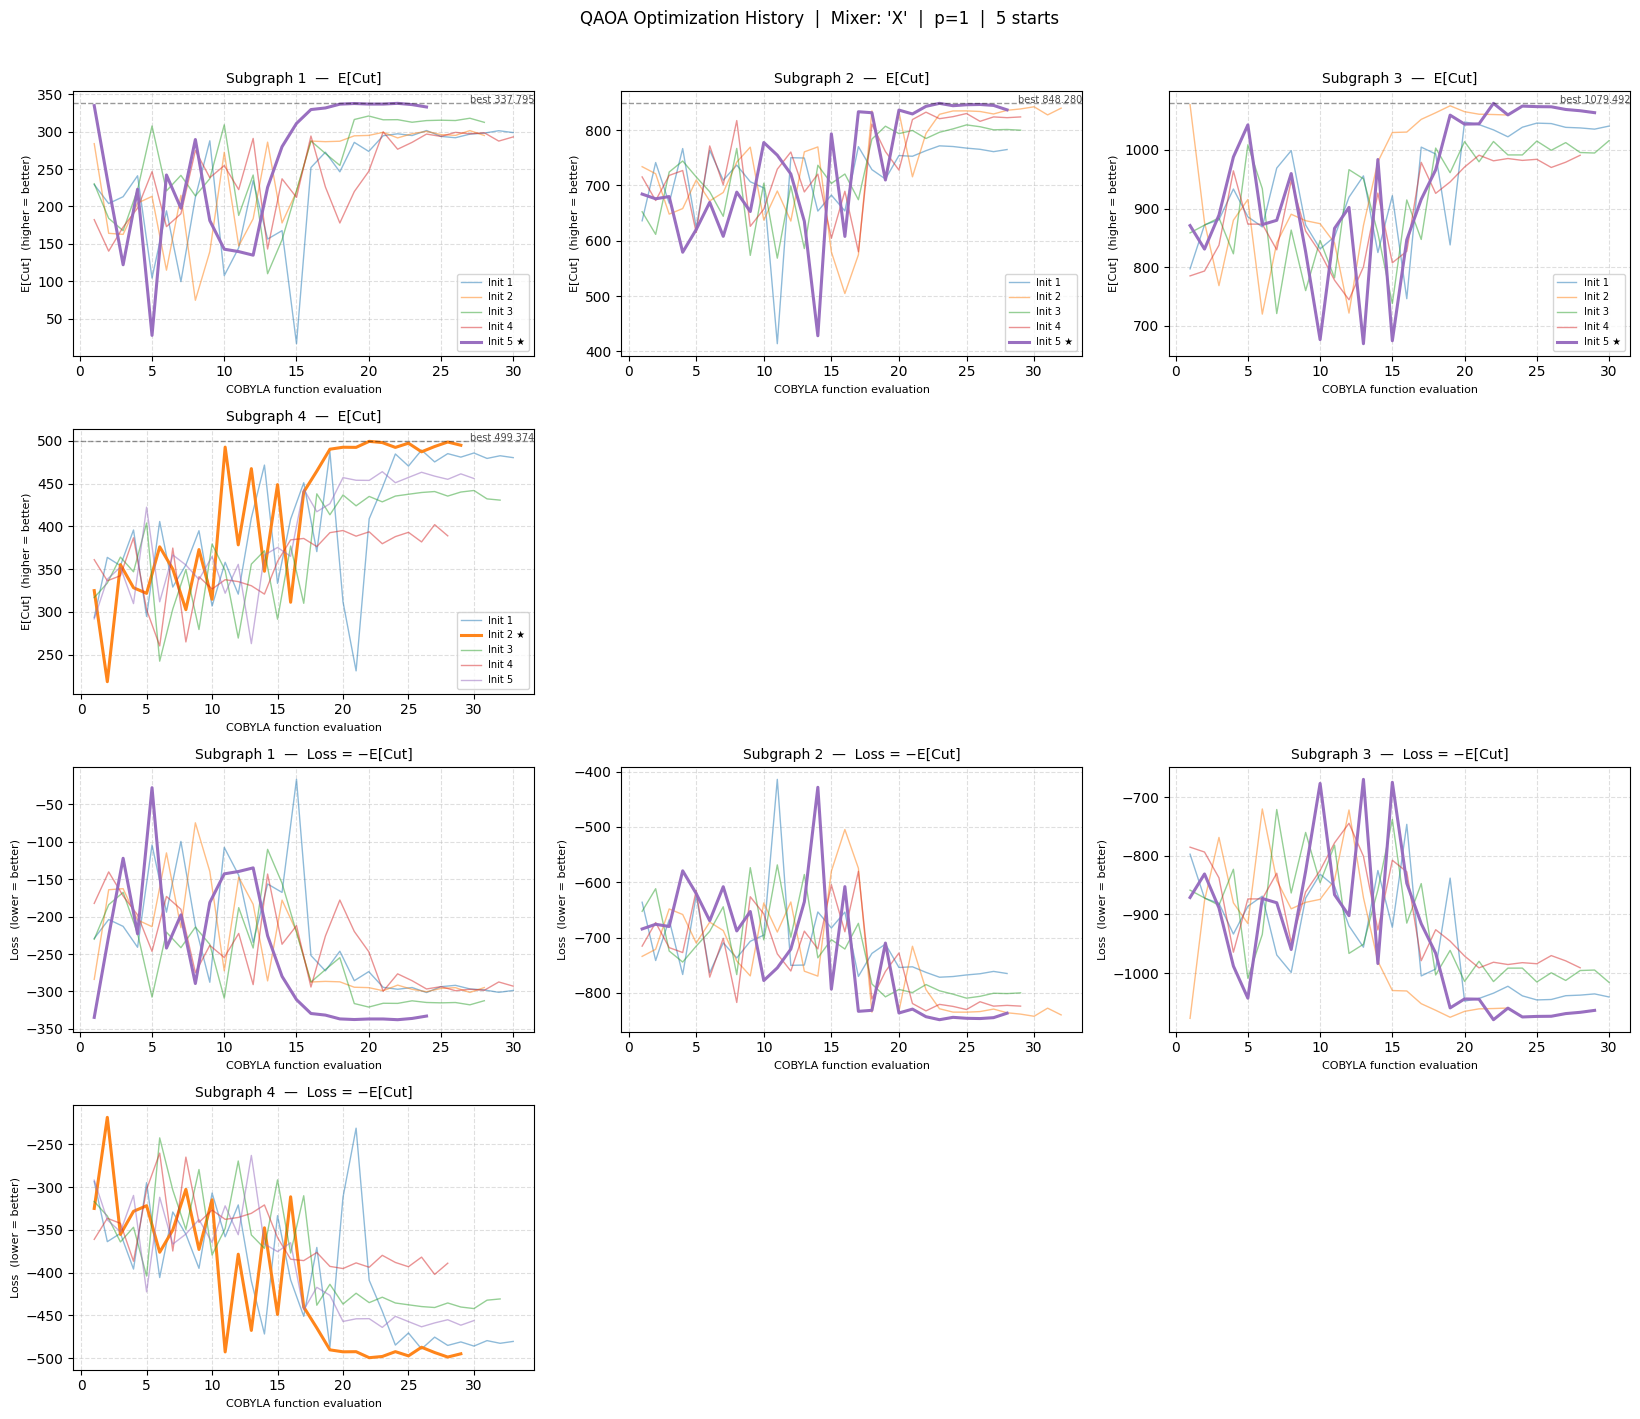


Subgraph      Trials  Iters/trial  Best E[Cut]
────────────────────────────────────────────────
1                  5         28.0     337.7953
2                  5         29.2     848.2802
3                  5         28.0    1079.4924
4                  5         30.4     499.3736


In [7]:
import math

histories = _solver_module.OPTIMIZATION_HISTORY   # {subgraph_id: [[cut_per_iter], ...]}

if not histories:
    print("No optimization history found.  Make sure USE_PYQUIL=True and re-run Step 4.")
else:
    num_sg = len(histories)
    cols   = min(3, num_sg)
    rows   = math.ceil(num_sg / cols)

    # ── One figure with 2 rows of panels: E[Cut] on top, Loss on bottom ──────
    fig, all_axes = plt.subplots(
        rows * 2, cols,
        figsize=(5.5 * cols, 3.5 * rows * 2),
        squeeze=False,
    )
    cut_axes  = all_axes[:rows]   # top half  → E[Cut]
    loss_axes = all_axes[rows:]   # bottom half → Loss = -E[Cut]

    cmap = plt.cm.tab10

    for sg_idx, (subgraph_id, trials) in enumerate(histories.items()):
        row, col = divmod(sg_idx, cols)
        ax_cut  = cut_axes[row][col]
        ax_loss = loss_axes[row][col]

        best_trial_idx = max(range(len(trials)), key=lambda t: max(trials[t], default=-1e9))

        for t_idx, trace in enumerate(trials):
            iterations = range(1, len(trace) + 1)
            is_best    = (t_idx == best_trial_idx)
            lw         = 2.2 if is_best else 1.0
            alpha      = 0.95 if is_best else 0.5
            label      = f"Init {t_idx+1}" + (" ★" if is_best else "")
            color      = cmap(t_idx % 10)

            loss_trace = [-v for v in trace]   # COBYLA minimised this

            ax_cut.plot(iterations, trace,      color=color, lw=lw, alpha=alpha, label=label)
            ax_loss.plot(iterations, loss_trace, color=color, lw=lw, alpha=alpha, label=label)

        # Annotate best final E[Cut]
        best_val = max(max(t, default=0) for t in trials)
        ax_cut.axhline(best_val, color="black", lw=1.0, ls="--", alpha=0.4)
        ax_cut.annotate(
            f"best {best_val:.3f}",
            xy=(1, best_val), xycoords=("axes fraction", "data"),
            fontsize=7, ha="right", color="black", alpha=0.7,
        )

        # ── Titles & labels ──
        ax_cut.set_title(f"Subgraph {sg_idx+1}  —  E[Cut]", fontsize=10)
        ax_cut.set_xlabel("COBYLA function evaluation", fontsize=8)
        ax_cut.set_ylabel("E[Cut]  (higher = better)", fontsize=8)
        ax_cut.grid(True, ls="--", alpha=0.4)
        if len(trials) <= 6:
            ax_cut.legend(fontsize=7, loc="lower right")

        ax_loss.set_title(f"Subgraph {sg_idx+1}  —  Loss = −E[Cut]", fontsize=10)
        ax_loss.set_xlabel("COBYLA function evaluation", fontsize=8)
        ax_loss.set_ylabel("Loss  (lower = better)", fontsize=8)
        ax_loss.grid(True, ls="--", alpha=0.4)

    # Hide empty subplots
    for sg_idx in range(num_sg, rows * cols):
        row, col = divmod(sg_idx, cols)
        cut_axes[row][col].set_visible(False)
        loss_axes[row][col].set_visible(False)

    fig.suptitle(
        f"QAOA Optimization History  |  Mixer: {_solver_module.MIXER_MODE!r}  "
        f"|  p={_solver_module.LAYER_COUNT}  |  {_solver_module.NUM_STARTS} starts",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Subgraph':<12} {'Trials':>7} {'Iters/trial':>12} {'Best E[Cut]':>12}")
    print("─" * 48)
    for sg_idx, (sid, trials) in enumerate(histories.items()):
        best_v   = max(max(t, default=0) for t in trials)
        avg_iter = sum(len(t) for t in trials) / len(trials) if trials else 0
        print(f"{sg_idx+1:<12} {len(trials):>7} {avg_iter:>12.1f} {best_v:>12.4f}")


## 5. Merger & GR Policy

In [8]:
print("\nMerging subgraphs via GR policy...")
best_assignment = merge(G, partition_tree, subgraph_solutions, top_t=TOP_T)

# Ensure all nodes have an assignment (fallback to +1)
for n in G.nodes():
    if n not in best_assignment:
        best_assignment[n] = 1

pre_polish_score = maxcut_score(G, best_assignment)
print(f"\nPre-polish Max-Cut Score: {pre_polish_score:.4f}")


Merging subgraphs via GR policy...
[merger] Merged internal node: score=2729.6140, |S|=1, pairs=100, candidates_kept=10
[merger] Merged internal node: score=3380.7952, |S|=1, pairs=100, candidates_kept=10
[merger] Merged internal node: score=3728.4132, |S|=1, pairs=80, candidates_kept=10
[merger] Final score on full graph: 3728.4132

Pre-polish Max-Cut Score: 3728.4132


## 6. Local Search Polish & Final Result

In [9]:
print("Running fast local search pass to polish border assignments...")
best_assignment = _local_search(G, list(G.nodes()), best_assignment)
final_score = maxcut_score(G, best_assignment)

total_weight = sum(d.get("weight", 1.0) for _, _, d in G.edges(data=True))

print(f"\n{'=' * 50}")
print(f"  FINAL RESULTS")
print(f"{'=' * 50}")
print(f"Pre-Polish Score : {pre_polish_score:.4f}")
print(f"Final Score      : {final_score:.4f} (+{final_score - pre_polish_score:.4f})")
print(f"Total Edge Weight: {total_weight:.4f}")
print(f"Approx Ratio     : {final_score / total_weight:.4f}")
print(f"{'=' * 50}")

Running fast local search pass to polish border assignments...

  FINAL RESULTS
Pre-Polish Score : 3728.4132
Final Score      : 3728.4132 (+0.0000)
Total Edge Weight: 4215.6655
Approx Ratio     : 0.8844


## 7. Visualize Final Cut Assignment

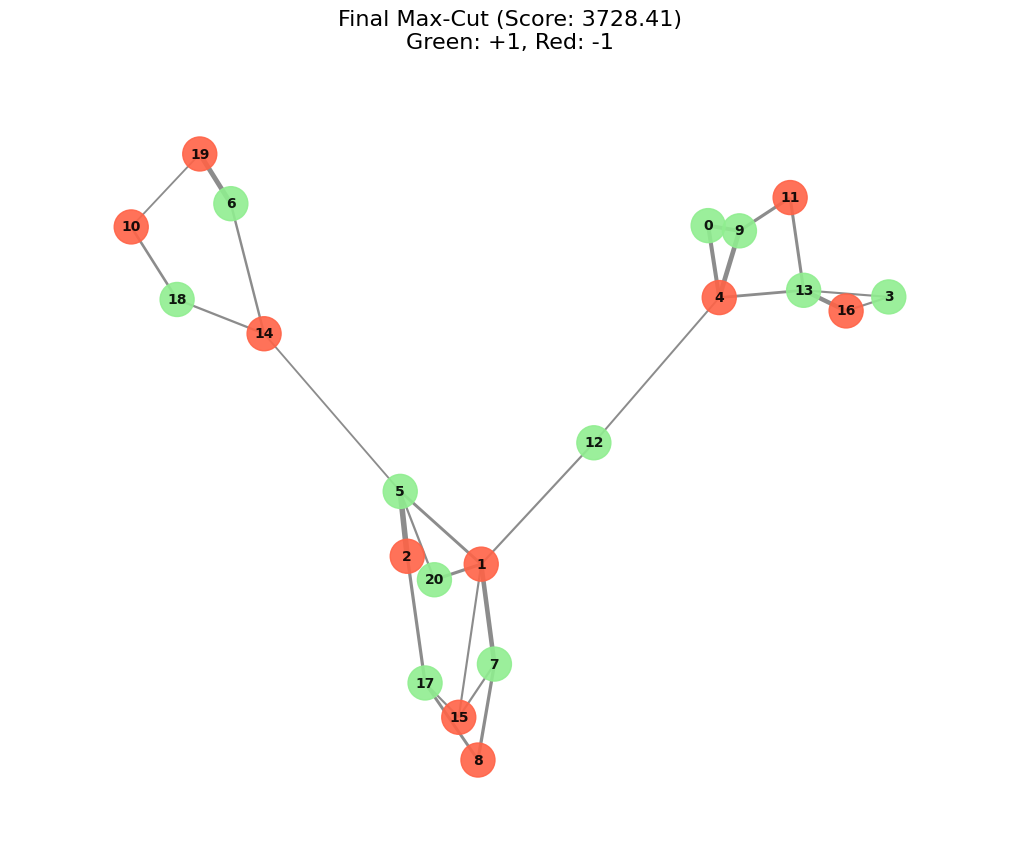

{3: array([1.       , 0.1469551]),
 13: array([0.7762576 , 0.15588401]),
 16: array([0.88788033, 0.12806527]),
 2: array([-0.26519432, -0.20239593]),
 5: array([-0.28365957, -0.11499815]),
 14: array([-0.64128794,  0.09735622]),
 20: array([-0.19377183, -0.23404657]),
 1: array([-0.07082085, -0.21300601]),
 7: array([-0.03614466, -0.34763449]),
 8: array([-0.07935429, -0.47688861]),
 17: array([-0.21837307, -0.37308141]),
 10: array([-0.99043144,  0.24123604]),
 19: array([-0.81030958,  0.33952301]),
 18: array([-0.86984825,  0.14350879]),
 6: array([-0.72861698,  0.27253807]),
 0: array([0.52542647, 0.2430052 ]),
 4: array([0.55453215, 0.14605341]),
 9: array([0.60756154, 0.23597654]),
 12: array([ 0.22513676, -0.04953437]),
 11: array([0.74082339, 0.28079528]),
 15: array([-0.12980546, -0.41931141])}

In [10]:
# +1 spin -> Lightgreen, -1 spin -> Tomato
color_map = {1: 'lightgreen', -1: 'tomato'}
final_colors = [color_map[best_assignment[n]] for n in G.nodes()]

draw_graph(G, f"Final Max-Cut (Score: {final_score:.2f})\nGreen: +1, Red: -1", 
           node_colors=final_colors, pos=global_pos)

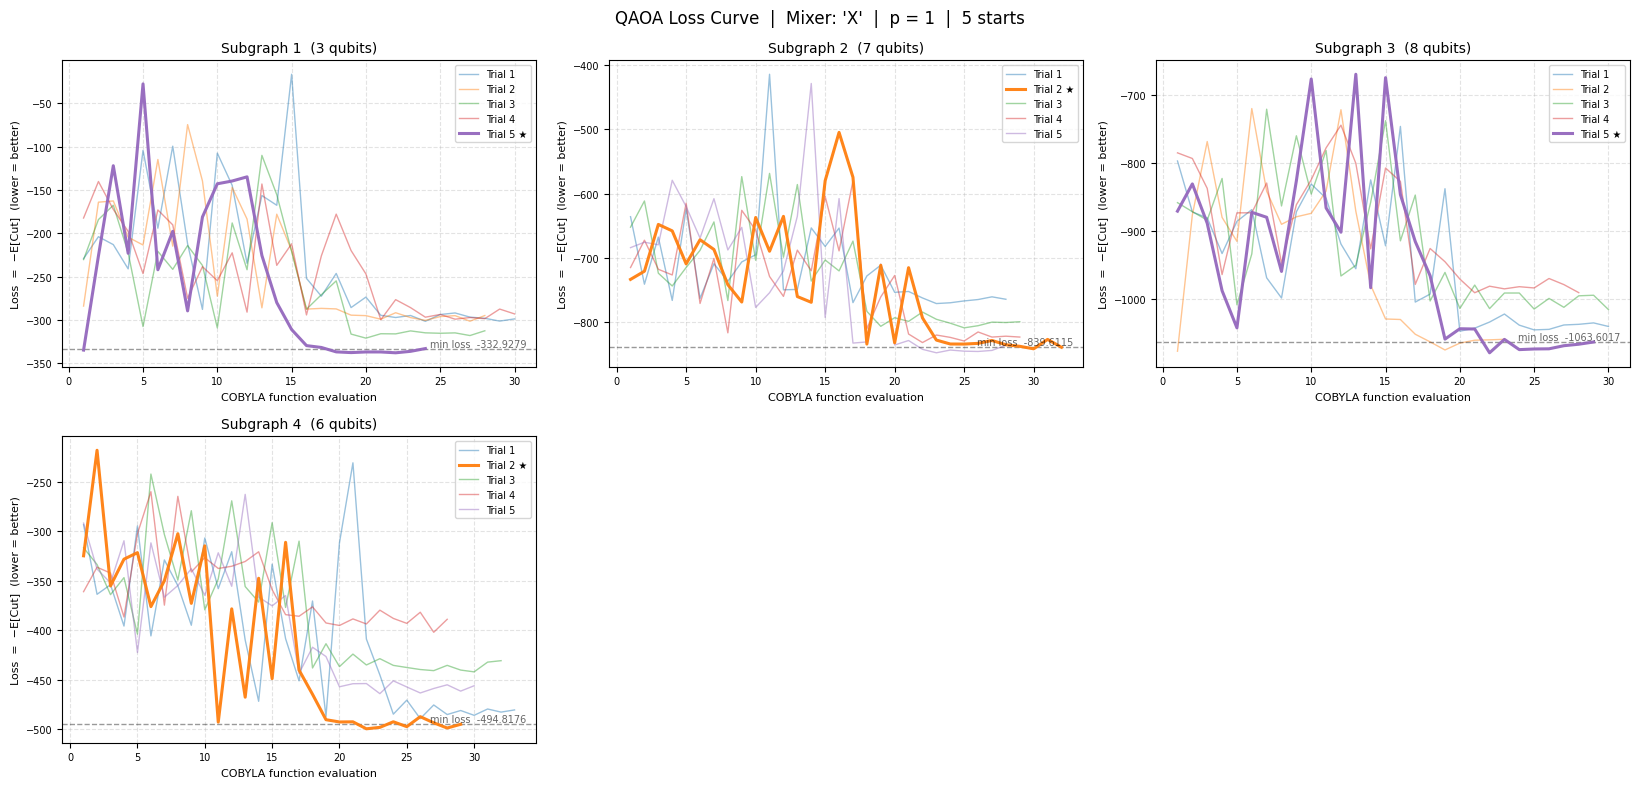


 SG  qubits  trials  evals/trial   min loss  best E[cut]    won
────────────────────────────────────────────────────────────
  1       3       5         28.0  -332.9279     332.9279    5/5
  2       7       5         29.2  -839.6115     839.6115    2/5
  3       8       5         28.0  -1063.6017    1063.6017    5/5
  4       6       5         30.4  -494.8176     494.8176    2/5


In [11]:
import math

histories    = _solver_module.OPTIMIZATION_HISTORY
final_params = _solver_module.FINAL_PARAMETERS

if not histories:
    print("No optimization history found. Make sure USE_PYQUIL=True and re-run Step 4.")
else:
    num_sg = len(histories)
    cols   = min(3, num_sg)
    rows   = math.ceil(num_sg / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4 * rows), squeeze=False)
    cmap = plt.cm.tab10

    for sg_idx, (sg_id, trials) in enumerate(histories.items()):
        row, col = divmod(sg_idx, cols)
        ax = axes[row][col]

        fp         = final_params.get(sg_id, {})
        best_trial = fp.get("best_trial", -1)
        best_e_cut = fp.get("best_e_cut", None)

        for t_idx, trace in enumerate(trials):
            if not trace:
                continue
            loss  = [-v for v in trace]           # loss = -E[cut]
            iters = range(1, len(loss) + 1)
            is_best = (t_idx == best_trial)
            ax.plot(
                iters, loss,
                color=cmap(t_idx % 10),
                lw=2.2 if is_best else 1.0,
                alpha=0.95 if is_best else 0.45,
                label=f"Trial {t_idx + 1}" + (" ★" if is_best else ""),
                zorder=3 if is_best else 2,
            )

        # Best loss reference line
        if best_e_cut is not None:
            ax.axhline(-best_e_cut, color="black", lw=1.0, ls="--", alpha=0.4)
            ax.annotate(
                f"min loss  {-best_e_cut:.4f}",
                xy=(0.98, -best_e_cut),
                xycoords=("axes fraction", "data"),
                fontsize=7, ha="right", va="bottom", color="black", alpha=0.6,
            )

        n_q = fp.get("n_qubits", "?")
        ax.set_title(f"Subgraph {sg_idx + 1}  ({n_q} qubits)", fontsize=10)
        ax.set_xlabel("COBYLA function evaluation", fontsize=8)
        ax.set_ylabel("Loss  =  −E[Cut]  (lower = better)", fontsize=8)
        ax.grid(True, ls="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if len(trials) <= 6:
            ax.legend(fontsize=7, loc="upper right")

    for sg_idx in range(num_sg, rows * cols):
        r, c = divmod(sg_idx, cols)
        axes[r][c].set_visible(False)

    fig.suptitle(
        f"QAOA Loss Curve  |  Mixer: {_solver_module.MIXER_MODE!r}"
        f"  |  p = {_solver_module.LAYER_COUNT}"
        f"  |  {_solver_module.NUM_STARTS} starts",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\n{'SG':>3}  {'qubits':>6}  {'trials':>6}  {'evals/trial':>11}  "
          f"{'min loss':>9}  {'best E[cut]':>11}  {'won':>5}")
    print("─" * 60)
    for sg_idx, (sg_id, trials) in enumerate(histories.items()):
        fp       = final_params.get(sg_id, {})
        n_q      = fp.get("n_qubits",   "?")
        ec       = fp.get("best_e_cut", None)
        won      = fp.get("best_trial", -1)
        avg_eval = sum(len(t) for t in trials) / len(trials) if trials else 0
        loss_s   = f"{-ec:.4f}" if ec is not None else "n/a"
        ec_s     = f"{ec:.4f}"  if ec is not None else "n/a"
        won_s    = f"{won+1}/{len(trials)}" if won >= 0 else "n/a"
        print(f"{sg_idx+1:>3}  {str(n_q):>6}  {len(trials):>6}  {avg_eval:>11.1f}  "
              f"{loss_s:>9}  {ec_s:>11}  {won_s:>5}")

/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_25291/2580645680.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)


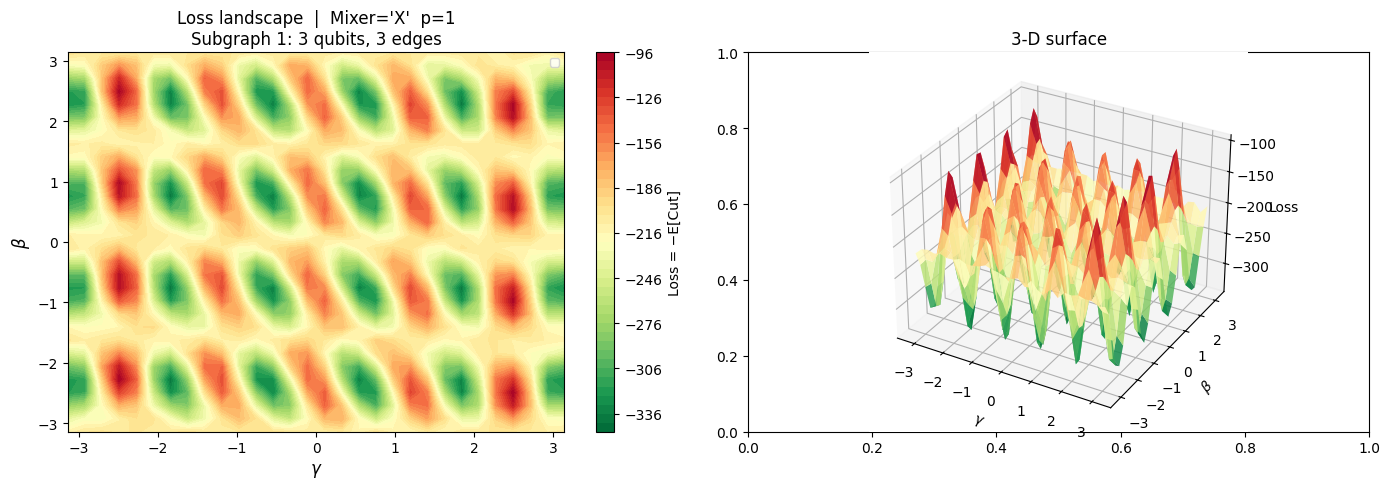

Grid minimum   γ=1.8416  β=0.7583  loss=-342.2207  E[cut]=342.2207


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Pick which leaf to survey ─────────────────────────────────────────────
LEAF_IDX  = 0           # change to inspect a different subgraph
GRID_SIZE = 30         

leaf      = leaves[LEAF_IDX]
nodes_sg  = list(leaf.graph.nodes())
n         = len(nodes_sg)
node_idx  = {v: i for i, v in enumerate(nodes_sg)}
edges_sg  = [
    (node_idx[u], node_idx[v], float(d.get("weight", 1.0)))
    for u, v, d in leaf.graph.edges(data=True)
]

# ── 2. Build and compile the p=1 circuit once ────────────────────────────────
import solver as _solver_module
from solver import _build_qaoa_program

prog       = _build_qaoa_program(n, edges_sg, p_layers=1,
                                  mixer_mode=_solver_module.MIXER_MODE)
executable = _solver_module._QC.compile(
    prog.wrap_in_numshots_loop(_solver_module.SHOTS)
)

# ── 3. Grid sweep ─────────────────────────────────────────────────────────────
gamma_vals = np.linspace(-np.pi, np.pi, GRID_SIZE)
beta_vals  = np.linspace(-np.pi, np.pi, GRID_SIZE)
Z_loss     = np.zeros((GRID_SIZE, GRID_SIZE))   # loss = -E[cut]

for i, g in enumerate(gamma_vals):
    for j, b in enumerate(beta_vals):
        result    = _solver_module._QC.run(
            executable,
            memory_map={"gammas": [float(g)], "betas": [float(b)]},
        )
        bits      = np.array(result.get_register_map().get("ro"))
        total_cut = sum(
            w
            for shot in bits
            for (u, v, w) in edges_sg
            if shot[u] != shot[v]
        )
        Z_loss[i, j] = -(total_cut / len(bits))    # store loss

# ── 4. Plot ───────────────────────────────────────────────────────────────────
G_grid, B_grid = np.meshgrid(gamma_vals, beta_vals, indexing="ij")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour map
cf = axes[0].contourf(G_grid, B_grid, Z_loss, levels=40, cmap="RdYlGn_r")
plt.colorbar(cf, ax=axes[0], label="Loss = −E[Cut]")
axes[0].set_xlabel(r"$\gamma$", fontsize=12)
axes[0].set_ylabel(r"$\beta$",  fontsize=12)
axes[0].set_title(
    f"Loss landscape  |  Mixer={_solver_module.MIXER_MODE!r}  p=1\n"
    f"Subgraph {LEAF_IDX+1}: {n} qubits, {len(edges_sg)} edges"
)

# Overlay the COBYLA starting points and converged points for this subgraph
sg_id   = id(leaf)
fp      = _solver_module.FINAL_PARAMETERS.get(sg_id, {})
history = _solver_module.OPTIMIZATION_HISTORY.get(sg_id, [])

if history:
    rng = np.random.default_rng(_solver_module.SEED)
    param_count = 2
    for t_idx in range(_solver_module.NUM_STARTS):
        g0, b0 = rng.uniform(-np.pi, np.pi, param_count)
        axes[0].scatter(g0, b0, marker="x", s=60, color="red",   zorder=5)
    axes[0].scatter([], [], marker="x", color="red",   label="COBYLA start")

if fp:
    g_opt, b_opt = fp["gammas"][0], fp["betas"][0]
    axes[0].scatter(g_opt, b_opt, marker="*", s=200, color="blue",
                    zorder=6, label=f"Optimal (trial {fp['best_trial']+1})")
axes[0].legend(fontsize=8)

# 3-D surface
ax3d = fig.add_subplot(1, 2, 2, projection="3d")
ax3d.plot_surface(G_grid, B_grid, Z_loss, cmap="RdYlGn_r", alpha=0.85)
ax3d.set_xlabel(r"$\gamma$")
ax3d.set_ylabel(r"$\beta$")
ax3d.set_zlabel("Loss")
ax3d.set_title("3-D surface")

plt.tight_layout()
plt.show()

# ── 5. Report grid minimum vs COBYLA result ───────────────────────────────────
grid_min_idx  = np.unravel_index(Z_loss.argmin(), Z_loss.shape)
grid_min_loss = Z_loss[grid_min_idx]
grid_g        = gamma_vals[grid_min_idx[0]]
grid_b        = beta_vals[grid_min_idx[1]]

print(f"Grid minimum   γ={grid_g:.4f}  β={grid_b:.4f}  loss={grid_min_loss:.4f}  E[cut]={-grid_min_loss:.4f}")
if fp:
    print(f"COBYLA result  γ={g_opt:.4f}  β={b_opt:.4f}  loss={-fp['best_e_cut']:.4f}  E[cut]={fp['best_e_cut']:.4f}")
    print(f"Gap (grid vs COBYLA): {abs(grid_min_loss - (-fp['best_e_cut'])):.4f}")

In [21]:
_solver_module.FINAL_PARAMETERS

{6291558480: {'gammas': [-2.3358830607560126],
  'betas': [-0.31141439029701745],
  'best_e_cut': 332.9278674375276,
  'best_trial': 4,
  'mixer_mode': 'X',
  'n_layers': 1,
  'n_qubits': 3},
 12930904784: {'gammas': [2.1553976842503135],
  'betas': [1.1962020071395054],
  'best_e_cut': 839.611521729492,
  'best_trial': 1,
  'mixer_mode': 'X',
  'n_layers': 1,
  'n_qubits': 7},
 12930904592: {'gammas': [-3.2840331459679635],
  'betas': [0.4781766927673915],
  'best_e_cut': 1063.601739294773,
  'best_trial': 4,
  'mixer_mode': 'X',
  'n_layers': 1,
  'n_qubits': 8},
 6291536976: {'gammas': [2.159925091092202],
  'betas': [1.7581632017884217],
  'best_e_cut': 494.8175512398095,
  'best_trial': 1,
  'mixer_mode': 'X',
  'n_layers': 1,
  'n_qubits': 6}}

In [39]:
subG = {
    0: 6291558480,
    1: 12930904784,
    2: 12930904592,
    3: 6291536976,
}

KeyError: 0

In [37]:
beta1 = _solver_module.FINAL_PARAMETERS[6291558480]['betas']
gamma1 = _solver_module.FINAL_PARAMETERS[6291558480]['gammas']

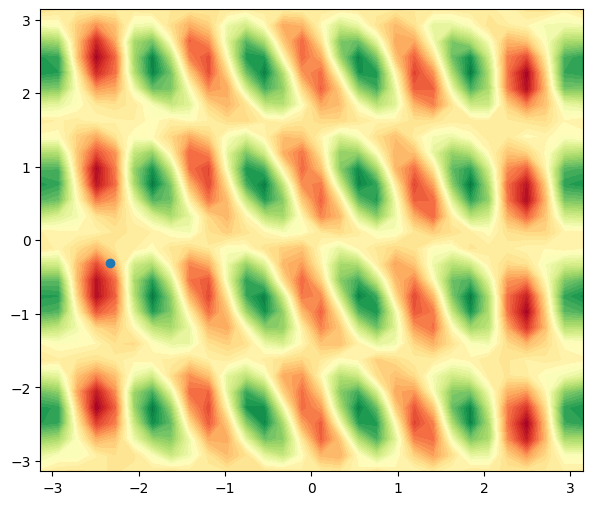

In [34]:
plt.figure(figsize=(7, 6))
plt.contourf(G_grid, B_grid, Z_loss, levels=40, cmap="RdYlGn_r")

plt.scatter(gamma1, beta1)


In [49]:
import numpy as np
import matplotlib.pyplot as plt
def plot_landscape(LEAF_IDX  = 0, MIXER_MODE = 'X', GRID_SIZE = 30):
    # ── 1. Pick which leaf to survey ─────────────────────────────────────────────     

    leaf      = leaves[LEAF_IDX]
    nodes_sg  = list(leaf.graph.nodes())
    n         = len(nodes_sg)
    node_idx  = {v: i for i, v in enumerate(nodes_sg)}
    edges_sg  = [
        (node_idx[u], node_idx[v], float(d.get("weight", 1.0)))
        for u, v, d in leaf.graph.edges(data=True)
    ]

    # ── 2. Build and compile the p=1 circuit once ────────────────────────────────
    import solver as _solver_module
    from solver import _build_qaoa_program

    prog       = _build_qaoa_program(n, edges_sg, p_layers=1,
                                    mixer_mode=MIXER_MODE)
    executable = _solver_module._QC.compile(
        prog.wrap_in_numshots_loop(_solver_module.SHOTS)
    )

    # ── 3. Grid sweep ─────────────────────────────────────────────────────────────
    gamma_vals = np.linspace(-np.pi, np.pi, GRID_SIZE)
    beta_vals  = np.linspace(-np.pi, np.pi, GRID_SIZE)
    Z_loss     = np.zeros((GRID_SIZE, GRID_SIZE))   # loss = -E[cut]

    for i, g in enumerate(gamma_vals):
        for j, b in enumerate(beta_vals):
            result    = _solver_module._QC.run(
                executable,
                memory_map={"gammas": [float(g)], "betas": [float(b)]},
            )
            bits      = np.array(result.get_register_map().get("ro"))
            total_cut = sum(
                w
                for shot in bits
                for (u, v, w) in edges_sg
                if shot[u] != shot[v]
            )
            Z_loss[i, j] = -(total_cut / len(bits))    # store loss

    # ── 4. Plot ───────────────────────────────────────────────────────────────────
    G_grid, B_grid = np.meshgrid(gamma_vals, beta_vals, indexing="ij")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Contour map
    cf = axes[0].contourf(G_grid, B_grid, Z_loss, levels=40, cmap="RdYlGn_r")
    plt.colorbar(cf, ax=axes[0], label="Loss = −E[Cut]")
    axes[0].set_xlabel(r"$\gamma$", fontsize=12)
    axes[0].set_ylabel(r"$\beta$",  fontsize=12)
    axes[0].set_title(
        f"Loss landscape  |  Mixer={_solver_module.MIXER_MODE!r}  p=1\n"
        f"Subgraph {LEAF_IDX+1}: {n} qubits, {len(edges_sg)} edges"
    )

    # Overlay the COBYLA starting points and converged points for this subgraph
    sg_id   = id(leaf)
    fp      = _solver_module.FINAL_PARAMETERS.get(sg_id, {})
    history = _solver_module.OPTIMIZATION_HISTORY.get(sg_id, [])

    if history:
        rng = np.random.default_rng(_solver_module.SEED)
        param_count = 2
        for t_idx in range(_solver_module.NUM_STARTS):
            g0, b0 = rng.uniform(-np.pi, np.pi, param_count)
            axes[0].scatter(g0, b0, marker="x", s=60, color="red",   zorder=5)
        axes[0].scatter([], [], marker="x", color="red",   label="COBYLA start")

    if fp:
        g_opt, b_opt = fp["gammas"][0], fp["betas"][0]
        axes[0].scatter(g_opt, b_opt, marker="*", s=200, color="blue",
                        zorder=6, label=f"Optimal (trial {fp['best_trial']+1})")
    axes[0].legend(fontsize=8)

    # 3-D surface
    ax3d = fig.add_subplot(1, 2, 2, projection="3d")
    ax3d.plot_surface(G_grid, B_grid, Z_loss, cmap="RdYlGn_r", alpha=0.85)
    ax3d.set_xlabel(r"$\gamma$")
    ax3d.set_ylabel(r"$\beta$")
    ax3d.set_zlabel("Loss")
    ax3d.set_title("3-D surface")

    plt.tight_layout()


    # ── 5. Report grid minimum vs COBYLA result ───────────────────────────────────
    grid_min_idx  = np.unravel_index(Z_loss.argmin(), Z_loss.shape)
    grid_min_loss = Z_loss[grid_min_idx]
    grid_g        = gamma_vals[grid_min_idx[0]]
    grid_b        = beta_vals[grid_min_idx[1]]

    print(f"Grid minimum   γ={grid_g:.4f}  β={grid_b:.4f}  loss={grid_min_loss:.4f}  E[cut]={-grid_min_loss:.4f}")
    if fp:
        print(f"COBYLA result  γ={g_opt:.4f}  β={b_opt:.4f}  loss={-fp['best_e_cut']:.4f}  E[cut]={fp['best_e_cut']:.4f}")
        print(f"Gap (grid vs COBYLA): {abs(grid_min_loss - (-fp['best_e_cut'])):.4f}")

    subG = {
    0: 6291558480,
    1: 12930904784,
    2: 12930904592,
    3: 6291536976, 
    }   
    beta = _solver_module.FINAL_PARAMETERS[subG[LEAF_IDX]]['betas']
    gamma = _solver_module.FINAL_PARAMETERS[subG[LEAF_IDX]]['gammas']
    axes[0].scatter(gamma, beta, label = 'optimized opint')
    axes[0].legend()

    
    print(f"Grid minimum   γ={grid_g:.4f}  β={grid_b:.4f}  "
          f"loss={grid_min_loss:.4f}  E[cut]={-grid_min_loss:.4f}")

    return (
        grid_b,
        fp["best_e_cut"] if fp else None,
        abs(grid_min_loss - (-fp["best_e_cut"])) if fp else None,
    )

Grid minimum   γ=-2.2749  β=0.3250  loss=-789.5036  E[cut]=789.5036
Grid minimum   γ=-2.2749  β=0.3250  loss=-789.5036  E[cut]=789.5036


/var/folders/cn/1yhq64td3_j1p23cdwjs4xsh0000gn/T/ipykernel_25291/3091209769.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8)


(0.3249923434748063, None, None)

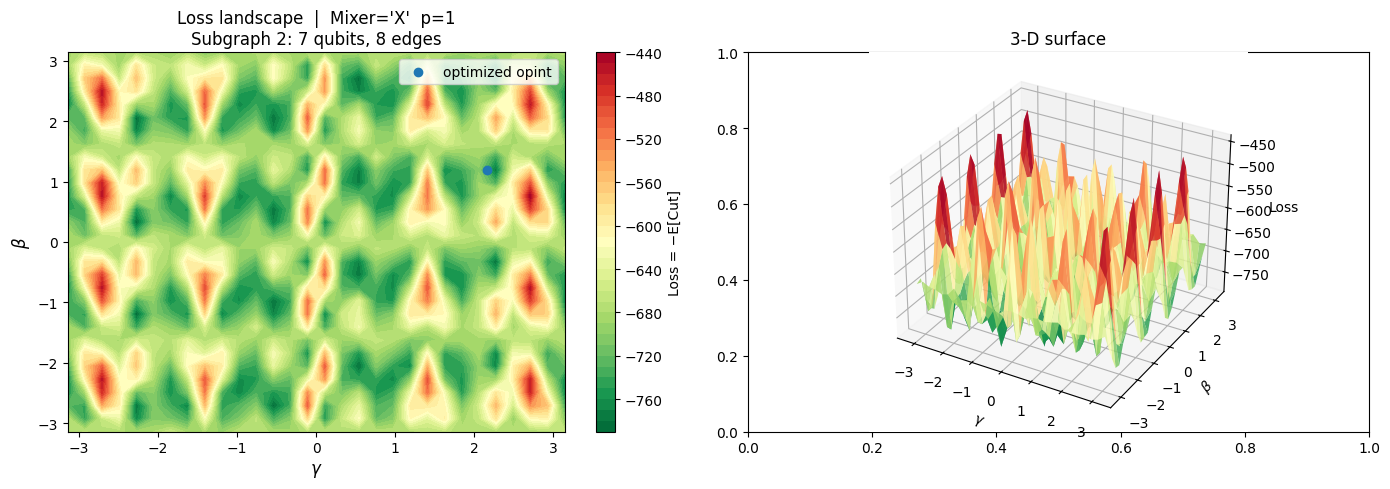

In [52]:
plot_landscape(LEAF_IDX  = 1, MIXER_MODE = 'X', GRID_SIZE = 30)

In [40]:
subG = {
    0: 6291558480,
    1: 12930904784,
    2: 12930904592,
    3: 6291536976,
}
subG[0]

6291558480

# Experiment for different mixer

In [ ]:


def experiment_mixer(METHOD     = "separator"):
    mixs = ["X", "XX", "XY"]
    _MIXER_DESCRIPTIONS = {
    "X":  ("Standard transverse-field",
           "exp(-i β Σ X_j)  — single-qubit RX rotations, lowest gate cost"),
    "XX": ("Graph-coupled XX",
           "exp(-i β Σ_{ring} X_iX_j)  — two-qubit XX on ring, richer correlations"),
    "XY": ("XY conserving mixer",
           "exp(-i β Σ_{ring} (X_iX_j+Y_iY_j)/2)  — preserves Hamming weight"),
}
    for MIXER_MODE in mixs:
       if MIXER_MODE not in _MIXER_DESCRIPTIONS:
              raise ValueError(f"Unknown MIXER_MODE {MIXER_MODE!r}. Choose from {list(_MIXER_DESCRIPTIONS)}")
              
       _solver_module.MIXER_MODE = MIXER_MODE
       name, formula = _MIXER_DESCRIPTIONS[MIXER_MODE]
       print(f"{'─'*55}")
       print(f"  Mixer mode  : {MIXER_MODE!r}")
       print(f"  Name        : {name}")
       print(f"  Operator    : {formula}")
       print(f"{'─'*55}")
       
       print(f"Partitioning graph (method={METHOD}, max_size={MAX_SIZE})...")
       partition_tree = recursive_partition(G, max_size=MAX_SIZE, method=METHOD)
       leaves = partition_tree.leaves()
       print(f"Created {len(leaves)} leaf subgraphs.")

       node_to_leaf_idx = {}
       for i, leaf in enumerate(leaves):
              for node in leaf.graph.nodes():
                     if node not in node_to_leaf_idx:
                            node_to_leaf_idx[node] = i

       # Map indices to unique colors
       cmap = plt.cm.get_cmap('tab20', len(leaves))
       colors = [cmap(node_to_leaf_idx.get(n, 0)) for n in G.nodes()]

       draw_graph(G, f"Partitioned Graph ({len(leaves)} Subgraphs)", node_colors=colors, pos=global_pos)

       subgraph_solutions = {}

       for i, leaf in enumerate(leaves):
              n_nodes = leaf.graph.number_of_nodes()
              backend = "pyQuil" if _solver_module.USE_PYQUIL else "stub"
              print(f"\n--- Solving Leaf {i + 1}/{len(leaves)} ---")
              print(f"Nodes: {n_nodes}, Edges: {leaf.graph.number_of_edges()} [{backend}]")
              
              # Solve (QAOA or stub)
              solutions = qaoa_solve(leaf.graph, top_t=TOP_T)
              subgraph_solutions[id(leaf)] = solutions
              
              best = maxcut_score(leaf.graph, solutions[0]) if solutions else 0.0
              print(f"-> Found {len(solutions)} solution(s). Best subgraph cut = {best:.4f}")

       



# Case by case

In [ ]:
# ── Mixer mode selection ──────────────────────────────────────────────────────
# Set MIXER_MODE to one of: "X", "XX", "XY"
MIXER_MODE = "X"

_MIXER_DESCRIPTIONS = {
    "X":  ("Standard transverse-field",
           "exp(-i β Σ X_j)  — single-qubit RX rotations, lowest gate cost"),
    "XX": ("Graph-coupled XX",
           "exp(-i β Σ_{ring} X_iX_j)  — two-qubit XX on ring, richer correlations"),
    "XY": ("XY conserving mixer",
           "exp(-i β Σ_{ring} (X_iX_j+Y_iY_j)/2)  — preserves Hamming weight"),
}

if MIXER_MODE not in _MIXER_DESCRIPTIONS:
    raise ValueError(f"Unknown MIXER_MODE {MIXER_MODE!r}. Choose from {list(_MIXER_DESCRIPTIONS)}")

_solver_module.MIXER_MODE = MIXER_MODE
name, formula = _MIXER_DESCRIPTIONS[MIXER_MODE]

print(f"{'─'*55}")
print(f"  Mixer mode  : {MIXER_MODE!r}")
print(f"  Name        : {name}")
print(f"  Operator    : {formula}")
print(f"{'─'*55}")



In [ ]:
print(f"Partitioning graph (method={METHOD}, max_size={MAX_SIZE})...")
partition_tree = recursive_partition(G, max_size=MAX_SIZE, method=METHOD)
leaves = partition_tree.leaves()

print(f"Created {len(leaves)} leaf subgraphs.")

# Assign a distinct color index to each leaf subgraph
node_to_leaf_idx = {}
for i, leaf in enumerate(leaves):
    for node in leaf.graph.nodes():
        if node not in node_to_leaf_idx:
            node_to_leaf_idx[node] = i

# Map indices to unique colors
cmap = plt.cm.get_cmap('tab20', len(leaves))
colors = [cmap(node_to_leaf_idx.get(n, 0)) for n in G.nodes()]

draw_graph(G, f"Partitioned Graph ({len(leaves)} Subgraphs)", node_colors=colors, pos=global_pos)

In [ ]:
subgraph_solutions = {}

for i, leaf in enumerate(leaves):
    n_nodes = leaf.graph.number_of_nodes()
    backend = "pyQuil" if _solver_module.USE_PYQUIL else "stub"
    print(f"\n--- Solving Leaf {i + 1}/{len(leaves)} ---")
    print(f"Nodes: {n_nodes}, Edges: {leaf.graph.number_of_edges()} [{backend}]")
    
    # Solve (QAOA or stub)
    solutions = qaoa_solve(leaf.graph, top_t=TOP_T)
    subgraph_solutions[id(leaf)] = solutions
    
    best = maxcut_score(leaf.graph, solutions[0]) if solutions else 0.0
    print(f"-> Found {len(solutions)} solution(s). Best subgraph cut = {best:.4f}")